# **USANDO REDES FULLY CONNECTED EM PROBLEMAS DE REGRESSÃO LINEAR**

Nesse material, aplicarei uma Rede Neural Profunda (DNN) ao dataset *Boston Housing* para prever os valores de imóveis com base em diferentes variáveis e comparar com um modelo mais simples. Prever o valor de um imóvel é diferente de prever a qual classe pertence algum objeto, o primeiro é um problema de **regressão**, o segundo de **classificação**. 

**SOBRE O DATASET**

O dataset *Boston Housing* usado nesse material é um pequeno conjunto de dados de um estudo sobre como os preços dos imóveis se relacionam com o ar puro. Ele é dividido em um conjunto de treinamento com 404 exemplos e um conjunto de teste com 102 exemplos. Cada exemplo corresponde a um único imóvel e consiste em 13 variáveis de entrada, que descrevem vários aspectos do imóvel, e uma única variável de saída correspondente ao preço do imóvel. 

Assim como o *MNIST*, esse dataset está incluído no Keras.

## **Unidades de saída (output units)**

No outro material, falei sobre funções de ativação alternativas a *tanh*. Porém, ainda não falei nada sobre continuar ou não usando a *sigmoide logística* como unidade de saída. A justificativa de trocar a função de ativação de neurônios ocultos é evitar o desaparecimento de gradientes. No caso da unidade de saída, ela é escolhida com base no tipo de problema que a rede vai ser aplicada.

A escolha da função de *loss* está intimamente ligada à escolha da unidade de saída. 
* A unidade de saída **logística** é usada para problemas de **classificação binária**;
* A unidade de saída **softmax** é usada para problemas de **classificação multiclasse**;
* A unidade de saída **linear** é usada para problemas de **regressão**.

As funções de *loss* recomendadas para cada unidade de saída são, respectivamente, ***cross-entropy***, **cross-entropy categórica** e **MSE (erro quadrático médio)**.

### Unidade logística

É uma função em formato de S, cuja saída varia de 0 a 1, semelhante a uma função degrau, porém sem descontinuidades. Como dito acima, o caso de uso típico é para classificação binária. 

A sua função é:

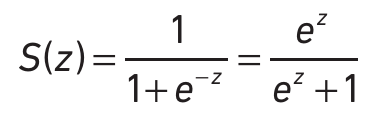 *Z é um valor real que pode ir de menos infinito até mais infinito. A saída é entre 0 e 1 e, por isso, pode ser interpretada como uma probabilidade.*

A função de *loss* recomendada para usar com esse tipo de unidade de saída é a *cross-entropy*:

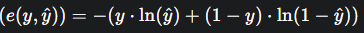 *Função de loss cross-entropy, onde y chapéu é a saída da função logística e y é o valor desejado.*

### Unidade softmax

A unidade *softmax* é uma generalização da *sigmoide logística* para múltiplas saídas. Quando analisamos a rede implementada para classificação multiclasse no material passado, utilizamos 10 instâncias da unidade *sigmoide logística*. Cada saída indicava se o exemplo pertencia ou não à classe e, no final, pegamos a maior saída como sendo a classe predita. No entanto, se somassemos todas as 10 saídas, esse valor provavelmente seria menor ou maior que 1. Ou seja, dificulta a interpretação como probabilidade. A definição da função *softmax* garante que essa soma das saídas seja igual a 1. A fórmula para a função *softmax* com n saída é:

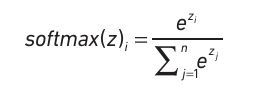

A unidade de saída *softmax* é aplicada sobre toda a camada de neurônios da saída, pois cada neurônio depende do valor de entrada dos outros neurônios. Isso ocorre devido à fórmula apresentada acima, onde o numerador representa o valor relacionado ao neurônio específico e o denominador à soma sobre todos os neurônios da camada. Isso garante que a soma de todas as saídas seja igual a 1.

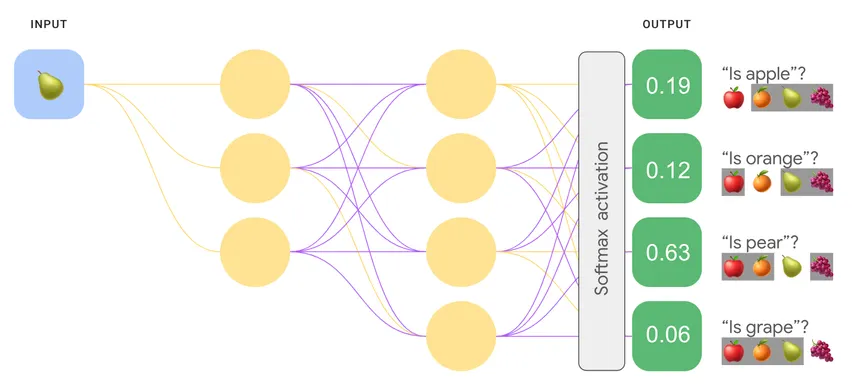 *Exemplo dessa aplicação em uma rede*

A função de *loss* recomendada para usar com esse tipo de unidade de saída é a ***cross-entropy* para classificação multiclasse**:

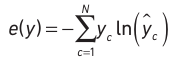 *Onde N é o número de saídas/classes*

Nota-se que, se o N for 2 e a função for expandida, ela resulta na função de *cross-entropy* comentada acima para classificação binária.

### Unidade linear

As unidades descritas acima são usadas em problemas de classificação. Agora, a unidade linear é usada para problemas de regressão, onde preciso prever um número qualquer, que não está limitado ao intervalo de 0 a 1, por exemplo, representa o preço de uma casa. Essa unidade de saída linear é tão simples quanto não ter nenhuma função, formalmente, a função de ativação é y=z, ou seja, a saída é a própria soma ponderada.

Uma unidade linear não possui problema com saturação, logo não há necessidade de usar a função de *loss cross-entropy*. Pode-se mostrar que uma boa função de perda é o erro quadrático médio (EQM). Isso faz sentido, pois o EQM é a função de erro usada na regressão linear, que é exatamente o que uma unidade de saída linear está fazendo.

Ao prever um valor com uma unidade linear, a acurácia não é uma boa métrica, pois é provável que nenhum exemplo seja previsto com exatidão. Logo, a verdadeira questão é quão próxima a previsão está do valor real. Para isso, a métrica mais significativa para avaliar o desempenho do modelo é o **erro absoluto médio**.

## **Hands-On: Predizendo os preços de casas com redes neurais profundas**

Padronizei tanto os dados de treino quanto os de teste usando a média e o desvio padrão dos dados de treinamento. O parâmetro *axis=0* garante que calculemos a média e o desvio padrão para cada variável de entrada separadamente. A média (e o desvio padrão) resultante é um vetor, em vez de um único valor. Ou seja, o valor padronizado da concentração de óxidos nítricos não é afetado pelos valores da taxa de criminalidade per capita ou de qualquer uma das outras variáveis.

Rede Neural Profunda (DNN) com duas camadas ocultas para predizer o preço das casas. 

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np
import logging

tf.get_logger().setLevel(logging.ERROR)
EPOCHS = 500
BATCH_SIZE = 16

#Carregando e normalizando o dataset Boston Housing
boston_housing = keras.datasets.boston_housing
(raw_x_train, y_train), (raw_x_test, y_test) = boston_housing.load_data()
x_mean = np.mean(raw_x_train, axis=0)
x_stddev = np.std(raw_x_train, axis=0)
x_train =(raw_x_train - x_mean) / x_stddev
x_test =(raw_x_test - x_mean) / x_stddev

#Criação e treinamento do modelo
model = Sequential()
model.add(Input(shape=[13]))  
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu')) #Com essa segunda camada oculta estamos fazendo uma rede neural profunda (DNN), ou seja, Deep Learning
model.add(Dense(1, activation='linear'))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])
model.summary() #Imprimir um resumo do modelo

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), 
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2, shuffle=True)

#Printar os 4 primeiros resultados
predictions = model.predict(x_test)
for i in range(0, 4):
    print('Prediction: ', predictions[i, 0], ', true value: ', y_test[i])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
26/26 - 1s - 30ms/step - loss: 535.6143 - mean_absolute_error: 21.2428 - val_loss: 499.3665 - val_mean_absolute_error: 20.4604
Epoch 2/500
26/26 - 0s - 4ms/step - loss: 394.6021 - mean_absolute_error: 17.7523 - val_loss: 305.6504 - val_mean_absolute_error: 15.4907
Epoch 3/500
26/26 - 0s - 4ms/step - loss: 193.6841 - mean_absolute_error: 11.5570 - val_loss: 108.6860 - val_mean_absolute_error: 8.7928
Epoch 4/500
26/26 - 0s - 4ms/step - loss: 73.2480 - mean_absolute_error: 6.5861 - val_loss: 57.8163 - val_mean_absolute_error: 6.1629
Epoch 5/500
26/26 - 0s - 4ms/step - loss: 43.2744 - mean_absolute_error: 4.9679 - val_loss: 39.0967 - val_mean_absolute_error: 5.0033
Epoch 6/500
26/26 - 0s - 4ms/step - loss: 29.8297 - mean_absolute_error: 4.0058 - val_loss: 33.4992 - val_mean_absolute_error: 4.5205
Epoch 7/500
26/26 - 0s - 4ms/step - loss: 24.9533 - mean_absolute_error: 3.5885 - val_loss: 30.0628 - val_mean_absolute_error: 4.2073
Epoch 8/500
26/26 - 0s - 4ms/step - loss: 22.2613 

Agora estamos com duas *hidden layers*, então estamos oficialmente fazendo *Deep Learning*. Mas, por que queremos mais camadas profundas? Vimos nos materiais anteriores que ter pelo menos uma *hidden layer* é importante para resolver a limitação com a separabilidade linear, mas não temos uma razão tão nítida para ter outras *hidden layers*. Teoricamente, uma camada oculta com neurônios suficientes é suficiente para aproximar qualquer função contínua. No entanto, na prática foi demonstrado que adicionar mais *hidden layers* ajuda a melhorar o desempenho das redes. Uma maneira de pensar sobre isso é que ter mais camadas ocultas pode permitir que a rede combine hierarquicamente as *features* em níveis crescentes de abstração.

A implementação da rede acima ficou com duas camadas ocultas de 64 neurônios e função de ativação *ReLU*, onde a primeira camada é declarada com 13 entradas para corresponder ao *dataset*. A camada de *output* consiste em um único neurônio com uma função de **ativação linear**. Usamos *MSE* como função de *loss* e o otimizador *Adam*.

Podemos ver que foi simples criar um modelo inicial e fazer algumas previsões razoáveis, mas é difícil dizer quão boas são essas previsões. Isso leva a uma pergunta que sempre faz sentido fazer: **Precisamos de DL para resolver o problema?** Como mostrado no material anterior, ajustar uma rede pode não ser trivial. Se existirem maneiras mais simples de resolver o problema, elas são preferíveis. Esse problema nos faz pensar no motivo de não termos usado uma **regressão linear simples**, por exemplo.

---------------------
------------

### Implementação como regressão linear

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np
import logging

tf.get_logger().setLevel(logging.ERROR)
EPOCHS = 500
BATCH_SIZE = 16

#Carregando e normalizando o dataset Boston Housing
boston_housing = keras.datasets.boston_housing
(raw_x_train, y_train), (raw_x_test, y_test) = boston_housing.load_data()
x_mean = np.mean(raw_x_train, axis=0)
x_stddev = np.std(raw_x_train, axis=0)
x_train =(raw_x_train - x_mean) / x_stddev
x_test =(raw_x_test - x_mean) / x_stddev

#Criação e treinamento do modelo
model = Sequential()
model.add(Input(shape=[13]))  
model.add(Dense(1, activation='linear'))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_absolute_error'])
model.summary() #Imprimir um resumo do modelo

history = model.fit(x_train, y_train, validation_data=(x_test, y_test), 
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2, shuffle=True)

#Printar os 4 primeiros resultados
predictions = model.predict(x_test)
for i in range(0, 4):
    print('Prediction: ', predictions[i, 0], ', true value: ', y_test[i])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │            14 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
26/26 - 0s - 18ms/step - loss: 572.2238 - mean_absolute_error: 22.3820 - val_loss: 596.5955 - val_mean_absolute_error: 23.0204
Epoch 2/500
26/26 - 0s - 4ms/step - loss: 570.0356 - mean_absolute_error: 22.3564 - val_loss: 594.0061 - val_mean_absolute_error: 22.9867
Epoch 3/500
26/26 - 0s - 4ms/step - loss: 567.9163 - mean_absolute_error: 22.3326 - val_loss: 591.4038 - val_mean_absolute_error: 22.9519
Epoch 4/500
26/26 - 0s - 4ms/step - loss: 565.7087 - mean_absolute_error: 22.3043 - val_loss: 588.9489 - val_mean_absolute_error: 22.9185
Epoch 5/500
26/26 - 0s - 4ms/step - loss: 563.6941 - mean_absolute_error: 22.2804 - val_loss: 586.4604 - val_mean_absolute_error: 22.8846
Epoch 6/500
26/26 - 0s - 4ms/step - loss: 561.6857 - mean_absolute_error: 22.2532 - val_loss: 584.3050 - val_mean_absolute_error: 22.8526
Epoch 7/500
26/26 - 0s - 4ms/step - loss: 559.8166 - mean_absolute_error: 22.2274 - val_loss: 582.0062 - val_mean_absolute_error: 22.8200
Epoch 8/500
26/26 - 0s - 7ms/step

Após executar o modelo acabei com um erro absoluto médio de  10,18. Claramente o modelo profundo se saiu melhor que a regressão.

---------------------
--------------

Agora vamos analisar se o modelo que treinamos com nossa rede está generalizando bem.

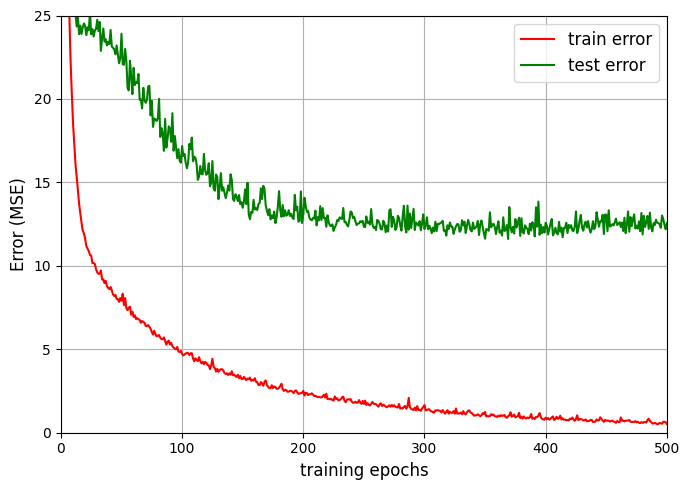

In [ ]:
import matplotlib.pyplot as plt

#Obtenha a perda de treinamento e validação do objeto history
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(loss) + 1)

#Plotar o erro de treinamento e validação
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, loss, color='red', label='train error') 
plt.plot(epochs_range, val_loss, color='green', label='test error')

#Rótulos dos eixos
plt.xlabel('training epochs', fontsize=12)
plt.ylabel('Error (MSE)', fontsize=12) 
plt.ylim(0, 25)
plt.yticks(range(0, 26, 5)) 

plt.xlim(0, EPOCHS) 
plt.xticks(range(0, EPOCHS + 1, 100))
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show() # Mostrar o gráfico

A figura acima mostra como os erros de treino e de teste mudaram de acordo com a quantidade de *epoch*. Com isso, nota-se que o erro de treinamento está diminuindo constantemente, mas o erro de teste está estável. Isso é um claro indicativo de *overfitting*.

----------
-----------

## **TÉCNICAS DE REGULARIZAÇÃO**

As técnicas que visam melhorar a generalização são conhecidas como **técnicas de regularização**. Especificamente, uma técnica de regularização visa reduzir a diferença entre o erro de treinamento e o erro de teste.  Uma técnica de regularização que já descrevi nos materiais é a parada antecipada (*early stopping*), mas essa técnica só é útil se o erro de teste apresentar uma curva em forma de U, ou seja, se o erro de teste começar a aumentar após um certo tempo. Porém, na imagem acima isso não ocorre.

Uma técnica de regularização comum é o decaimento de peso (**weight decay**). Ele é implementado adicionando um termo de penalidade à função de *loss*:

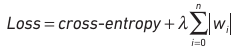 *onde λ é uma constante e w0, w1,…,wn são os pesos de todos os neurônios no modelo.*

O nosso algoritmo de aprendizado tenta sempre minimizar a função de *loss*, este termo de erro fornece um incentivo para minimizar os pesos. Isso resulta na diminuição de pesos que não contribuem significativamente para a solução do problema geral. Esses pesos que são úteis apenas para exemplos específicos de entrada, que não ajuda para o aprendizado do caso geral, serão diminuídos porque reduzem a *loss* apenas para uma pequena quantidade de exemplos. A partir disso, o decaimento de peso auxilia em uma melhor generalização. O parâmetro λ afeta o quão significativo será o efeito da regularização. Essa técnica mostrada na fórmula acima é conhecida como **regularização L1**.

Uma variação mais comum é elevar os pesos ao quadrado na soma, que é conhecida como **regularização L2**:

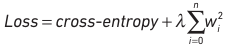

Mesmo que eu tenha usado a regularização de decaimento de pesos na função de *loss cross-entropy*, ela pode ser aplicada a qualquer função de *loss*. Do mesmo modo, ela também pode ser aplicada ao ML(*Machine Learning*) tradicional, não só ao DL(*Deep Learning*).

Implementação da regularização L2 pelo Keras

In [ ]:
from tensorflow.keras.regularizers import l2

model.add(Dense(64, activation='relu',
            kernel_regularizer=l2(0.1),
            bias_regularizer=l2(0.1),
            input_shape=[13]))
model.add(Dense(64, activation='relu',
            kernel_regularizer=l2(0.1),
            bias_regularizer=l2(0.1)))
model.add(Dense(1, activation='linear',
            kernel_regularizer=l2(0.1),
            bias_regularizer=l2(0.1)))

**DROPOUT**

O *Dropout* é outra técnica de regularização comum e eficaz, desenvolvida especificamente para redes neurais. Ele consiste em remover **aleatoriamente** um subconjunto de neurônios da rede durante o treinamento. O subconjunto de neurônios removidos varia ao longo de cada época de treinamento. O número de neurônios removidos (a taxa de dropout) é controlado por um parâmetro, onde um valor comum é 20%. Quando a rede é usada para inferência, todos os neurônios são utilizados, mas um fator de escala é aplicado a cada peso para compensar o fato de que cada neurônio agora recebe entradas de mais neurônios do que durante o treinamento.

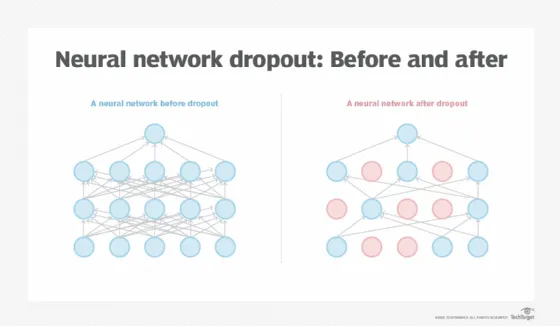

O *dropout* força as unidades a serem capazes de trabalhar com um conjunto aleatório de outras unidades. Fazer isso impede que subconjuntos de unidades se co-adaptem para resolver casos específicos e demonstrou-se que reduz o sobreajuste.

Como implementar *dropout* no Keras

In [ ]:
from tensorflow.keras.layers import Dropout
model.add(Dense(64, activation='relu', input_shape=[13]))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

O *dropout* é adicionado como uma camada adicional após a camada à qual queremos aplicá-lo. A camada *Dropout* bloqueará conexões de um subconjunto de neurônios da camada anterior, o que tem o mesmo efeito como se o neurônio não estivesse lá para começo de conversa.